# Analyse Exploratoire

### Import des modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Analyse Exploratoire

In [2]:
# Chargement des données
building_consumption = pd.read_csv("../2016_Building_Energy_Benchmarking.csv")

# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [3]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Variables à supprimer du jeu de données (peu/pas d'information pertinente, identifiants, texte libre):

In [4]:
# Colonnes à supprimer (ID, texte libre, biais) ---
columns_to_drop = [
    "OSEBuildingID",
    "DataYear",
    "PropertyName",
    "Address",
    "City",
    "State",
    "ZipCode",
    "TaxParcelIdentificationNumber",
    "PropertyGFATotal",
    "PropertyGFAParking",
    "Comments",
    "DefaultData",
    "Outlier",
]
# Suppression
building_consumption = building_consumption.drop(columns=columns_to_drop)

print("Shape après suppression colonnes :", building_consumption.shape)

Shape après suppression colonnes : (3376, 33)


Analyse de BuildingType pour éliminer les bâtiments résidentiels

In [5]:
building_consumption[["BuildingType"]].value_counts()

BuildingType        
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

In [6]:
# Suppression des bâtiments résidentiels
residential_types = [
    "Multifamily LR (1-4)",
    "Multifamily MR (5-9)",
    "Multifamily HR (10+)"
]
building_consumption = building_consumption[~building_consumption["BuildingType"].isin(residential_types)]

print("Shape après suppression bâtiments résidentiels :", building_consumption.shape)

Shape après suppression bâtiments résidentiels : (1668, 33)


Variables à supprimer ayant un fort taux de manquants

In [7]:
# Nombre total de lignes
n_rows = len(building_consumption)

# Calcul du nombre et du pourcentage de valeurs manquantes
missing = pd.DataFrame({
    "nb_missing": building_consumption.isna().sum(),
    "pct_missing": (building_consumption.isna().sum() / n_rows) * 100
})

# On ne garde que les colonnes avec au moins 1 valeur manquante
missing = missing[missing["nb_missing"] > 0]

# Tri par pourcentage décroissant
missing = missing.sort_values(by="pct_missing", ascending=False)

missing

,nb_missing,pct_missing
YearsENERGYSTARCertified,1570,94.124700
ThirdLargestPropertyUseTypeGFA,1315,78.836930
ThirdLargestPropertyUseType,1315,78.836930
SecondLargestPropertyUseType,813,48.741007
SecondLargestPropertyUseTypeGFA,813,48.741007
ENERGYSTARScore,574,34.412470
LargestPropertyUseType,6,0.359712
LargestPropertyUseTypeGFA,6,0.359712
SiteEnergyUseWN(kBtu),3,0.179856
SiteEUIWN(kBtu/sf),3,0.179856


In [8]:
columns_high_missing = [
    "YearsENERGYSTARCertified",
    "ThirdLargestPropertyUseType",
    "ThirdLargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseType",
    "SecondLargestPropertyUseTypeGFA",
    "ENERGYSTARScore"
]

building_consumption = building_consumption.drop(columns=columns_high_missing)

print("Shape après suppression colonnes à fort taux de NA :", building_consumption.shape)

Shape après suppression colonnes à fort taux de NA : (1668, 27)


Analyse de ComplianceStatus pour supprimer les bâtiments non conformes

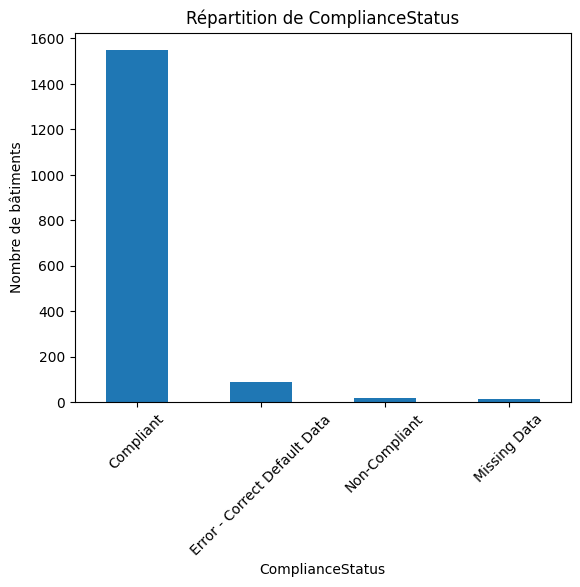

In [9]:
building_consumption["ComplianceStatus"].value_counts().plot(kind="bar")
plt.title("Répartition de ComplianceStatus")
plt.ylabel("Nombre de bâtiments")
plt.xticks(rotation=45)
plt.show()

In [10]:
# Ne conserver que les bâtiments "Compliant"
building_consumption = building_consumption[building_consumption["ComplianceStatus"] == "Compliant"]
# Supprimer la variable
building_consumption = building_consumption.drop(columns=["ComplianceStatus"])

print("Shape après traitement de la variable ComplianceStatus :", building_consumption.shape)

Shape après traitement de la variable ComplianceStatus : (1548, 26)


Analyse des variables Electricity(kWh), Electricity(kBtu), NaturalGas(therms) et NaturalGas(kBtu)

In [11]:
# Supprimer la variable
building_consumption = building_consumption.drop(columns=["Electricity(kWh)", "NaturalGas(therms)"])

print("Shape après suppression des énergies non exprimées en kBtu :", building_consumption.shape)

Shape après suppression des énergies non exprimées en kBtu : (1548, 24)


Analyse des variables spaciales CouncilDistrictCode (catégorielle), Neighborhood (catégorielle) et la paire Latitude/Longitude (numérique)

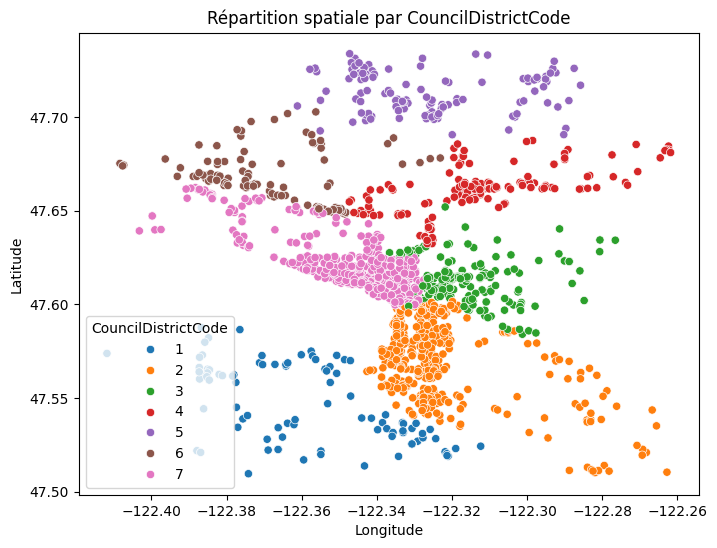

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=building_consumption,
    x="Longitude",
    y="Latitude",
    hue="CouncilDistrictCode",
    palette="tab10"
)
plt.title("Répartition spatiale par CouncilDistrictCode")
plt.show()

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

X = building_consumption[["Latitude", "Longitude"]]
y = building_consumption["CouncilDistrictCode"]

model = RandomForestClassifier()
scores = cross_val_score(model, X, y, cv=5)

scores.mean()

np.float64(0.960601315377388)

In [14]:
building_consumption = building_consumption.drop(columns=["CouncilDistrictCode"])

print("Shape après traitement de la variable CouncilDistrictCode :", building_consumption.shape)

Shape après traitement de la variable CouncilDistrictCode : (1548, 23)


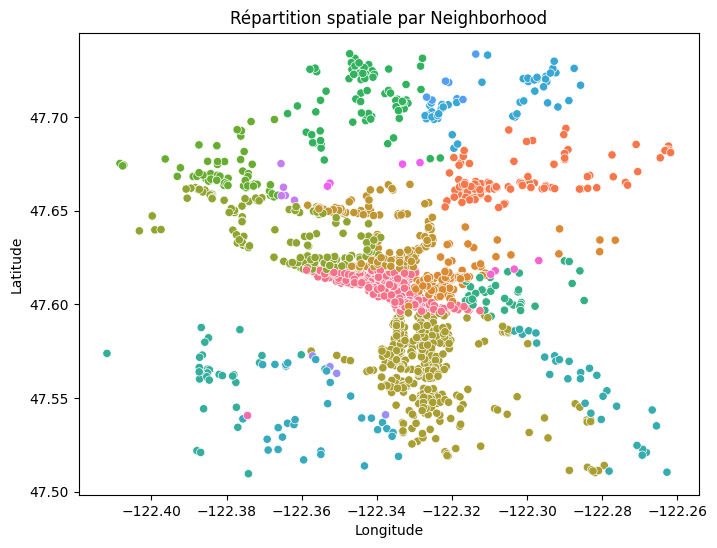

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=building_consumption,
    x="Longitude",
    y="Latitude",
    hue="Neighborhood",
    legend=False
)
plt.title("Répartition spatiale par Neighborhood")
plt.show()

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

X = building_consumption[["Latitude", "Longitude"]]
y = building_consumption["Neighborhood"]

model = RandomForestClassifier()
scores = cross_val_score(model, X, y, cv=5)

scores.mean()

C:\Users\ericg\AppData\Local\pypoetry\Cache\virtualenvs\projet-06-mQMbkt4E-py3.14\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


np.float64(0.9425159202421964)

In [17]:
building_consumption["Neighborhood"].value_counts()

Neighborhood
DOWNTOWN                  351
GREATER DUWAMISH          328
MAGNOLIA / QUEEN ANNE     144
LAKE UNION                143
NORTHEAST                 117
EAST                      116
NORTHWEST                  74
BALLARD                    58
NORTH                      51
CENTRAL                    42
DELRIDGE                   36
SOUTHWEST                  31
SOUTHEAST                  31
North                       8
Ballard                     5
Delridge                    4
Northwest                   4
Central                     4
DELRIDGE NEIGHBORHOODS      1
Name: count, dtype: int64

In [18]:
building_consumption = building_consumption.drop(columns=["Neighborhood"])

print("Shape après traitement de la variable Neighborhood :", building_consumption.shape)

Shape après traitement de la variable Neighborhood : (1548, 22)


In [19]:
building_consumption[["Latitude", "Longitude"]].describe()

,Latitude,Longitude
count,1548.000000,1548.000000
mean,47.616488,-122.333518
std,0.046954,0.023264
min,47.509590,-122.411820
25%,47.587855,-122.342997
50%,47.612710,-122.333160
75%,47.649060,-122.322700
max,47.733870,-122.261800


Analyse des variables énergétiques brutes et normalisées (WN).

In [20]:
building_consumption[["SiteEUI(kBtu/sf)", "SiteEUIWN(kBtu/sf)"]].corr()

,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf)
SiteEUI(kBtu/sf),1.00000,0.99283
SiteEUIWN(kBtu/sf),0.99283,1.00000


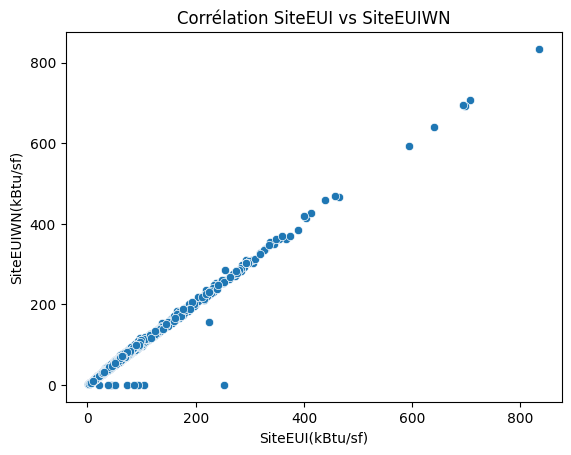

In [21]:
sns.scatterplot(
    data=building_consumption,
    x="SiteEUI(kBtu/sf)",
    y="SiteEUIWN(kBtu/sf)"
)

plt.title("Corrélation SiteEUI vs SiteEUIWN")
plt.show()

In [22]:
building_consumption[["SourceEUI(kBtu/sf)", "SourceEUIWN(kBtu/sf)"]].corr()

,SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf)
SourceEUI(kBtu/sf),1.000000,0.993705
SourceEUIWN(kBtu/sf),0.993705,1.000000


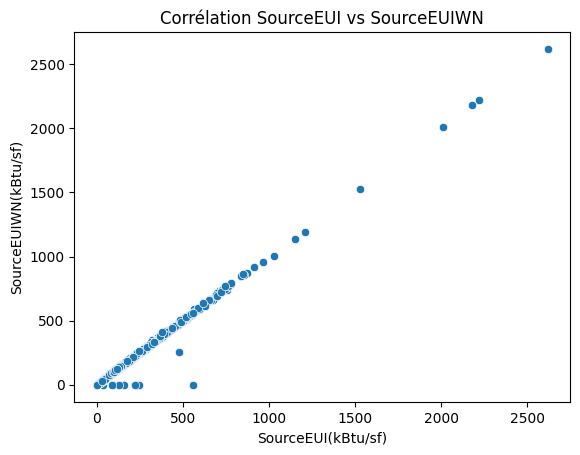

In [23]:
sns.scatterplot(
    data=building_consumption,
    x="SourceEUI(kBtu/sf)",
    y="SourceEUIWN(kBtu/sf)"
)

plt.title("Corrélation SourceEUI vs SourceEUIWN")
plt.show()

In [24]:
building_consumption[["SiteEnergyUse(kBtu)", "SiteEnergyUseWN(kBtu)"]].corr()

,SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu)
SiteEnergyUse(kBtu),1.000000,0.702474
SiteEnergyUseWN(kBtu),0.702474,1.000000


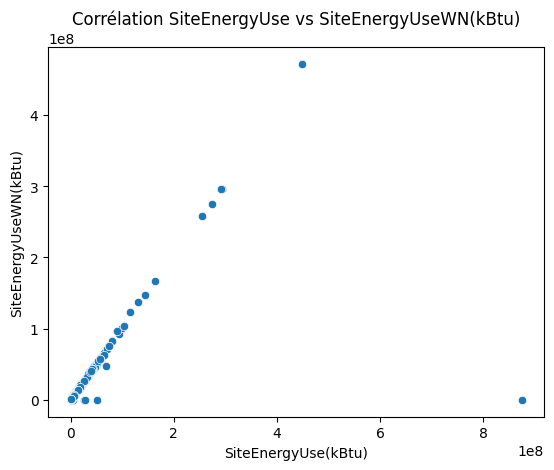

In [25]:
sns.scatterplot(
    data=building_consumption,
    x="SiteEnergyUse(kBtu)",
    y="SiteEnergyUseWN(kBtu)"
)

plt.title("Corrélation SiteEnergyUse vs SiteEnergyUseWN(kBtu)")
plt.show()

In [26]:
building_consumption = building_consumption.drop(columns=["SiteEUI(kBtu/sf)"])
building_consumption = building_consumption.drop(columns=["SourceEUI(kBtu/sf)"])
building_consumption = building_consumption.drop(columns=["SiteEnergyUse(kBtu)"])

print("Shape après suppression des variables énergétiques brutes :", building_consumption.shape)

Shape après suppression des variables énergétiques brutes : (1548, 19)


In [27]:
building_consumption = building_consumption.drop(columns=["SourceEUIWN(kBtu/sf)","SiteEnergyUseWN(kBtu)"])

print("Shape après traitement des variables énergétiques redondantes :", building_consumption.shape)

Shape après traitement des variables énergétiques redondantes : (1548, 17)


Analyse des variables d'émission

In [28]:
building_consumption[["SiteEUIWN(kBtu/sf)","TotalGHGEmissions"]].corr()

,SiteEUIWN(kBtu/sf),TotalGHGEmissions
SiteEUIWN(kBtu/sf),1.000000,0.242351
TotalGHGEmissions,0.242351,1.000000


In [29]:
building_consumption[["SiteEUIWN(kBtu/sf)","GHGEmissionsIntensity"]].corr()

,SiteEUIWN(kBtu/sf),GHGEmissionsIntensity
SiteEUIWN(kBtu/sf),1.00000,0.72707
GHGEmissionsIntensity,0.72707,1.00000


In [30]:
building_consumption = building_consumption.drop(columns=["TotalGHGEmissions","GHGEmissionsIntensity"])

print("Shape après suppression des variables d'émissions :", building_consumption.shape)

Shape après suppression des variables d'émissions : (1548, 15)


Variables numériques

In [31]:
numeric_cols = [
    "YearBuilt",
    "NumberofBuildings",
    "NumberofFloors",
    "PropertyGFABuilding(s)",
    "LargestPropertyUseTypeGFA"
]

building_consumption[numeric_cols].describe()

,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFABuilding(s),LargestPropertyUseTypeGFA
count,1548.000000,1548.000000,1548.000000,1.548000e+03,1.544000e+03
mean,1961.644057,1.178941,4.276486,1.074898e+05,9.994564e+04
std,32.886918,3.039221,6.780694,2.926272e+05,2.855014e+05
min,1900.000000,0.000000,0.000000,3.636000e+03,5.656000e+03
25%,1930.000000,1.000000,1.000000,2.793675e+04,2.501575e+04
50%,1965.500000,1.000000,2.000000,4.608400e+04,4.204300e+04
75%,1989.000000,1.000000,4.000000,9.556825e+04,9.203675e+04
max,2015.000000,111.000000,99.000000,9.320156e+06,9.320156e+06


In [32]:
(building_consumption["NumberofBuildings"] == 0).sum()

np.int64(52)

In [33]:
building_consumption.loc[building_consumption["NumberofBuildings"] == 0, "NumberofBuildings"] = 1

In [34]:
(building_consumption["NumberofFloors"] == 0).sum()

np.int64(16)

In [35]:
building_consumption.loc[building_consumption["NumberofFloors"] == 0, "NumberofFloors"] = 1

Liste des variables conservées (avec y = SiteEUIWN(kBtu/sf))

In [36]:
building_consumption.info()

<class 'pandas.DataFrame'>
Index: 1548 entries, 0 to 3375
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   BuildingType               1548 non-null   str    
 1   PrimaryPropertyType        1548 non-null   str    
 2   Latitude                   1548 non-null   float64
 3   Longitude                  1548 non-null   float64
 4   YearBuilt                  1548 non-null   int64  
 5   NumberofBuildings          1548 non-null   float64
 6   NumberofFloors             1548 non-null   int64  
 7   PropertyGFABuilding(s)     1548 non-null   int64  
 8   ListOfAllPropertyUseTypes  1548 non-null   str    
 9   LargestPropertyUseType     1544 non-null   str    
 10  LargestPropertyUseTypeGFA  1544 non-null   float64
 11  SiteEUIWN(kBtu/sf)         1547 non-null   float64
 12  SteamUse(kBtu)             1548 non-null   float64
 13  Electricity(kBtu)          1548 non-null   float64
 14  NaturalG

Traitement des manquants

In [37]:
# Calcul du nombre et du pourcentage de valeurs manquantes
missing = pd.DataFrame({"nb_missing": building_consumption.isna().sum(),})

# On ne garde que les colonnes avec au moins 1 valeur manquante
missing = missing[missing["nb_missing"] > 0]

# Tri par pourcentage décroissant
missing = missing.sort_values(by="nb_missing", ascending=False)

missing

,nb_missing
LargestPropertyUseType,4
LargestPropertyUseTypeGFA,4
SiteEUIWN(kBtu/sf),1


In [38]:
building_consumption = building_consumption.dropna(subset=["SiteEUIWN(kBtu/sf)"])

print("Shape après suppression des valeurs cible manquantes :", building_consumption.shape)

Shape après suppression des valeurs cible manquantes : (1547, 15)


In [39]:
cols_to_display = [
    "PrimaryPropertyType",
    "ListOfAllPropertyUseTypes",
    "LargestPropertyUseType",
    "PropertyGFABuilding(s)",
    "LargestPropertyUseTypeGFA"
]

# Filtrer les lignes avec au moins un NA sur les variables concernées
missing_buildings = building_consumption[building_consumption[["LargestPropertyUseType", "LargestPropertyUseTypeGFA"]].isna().any(axis=1)]

missing_buildings[cols_to_display]

,PrimaryPropertyType,ListOfAllPropertyUseTypes,LargestPropertyUseType,PropertyGFABuilding(s),LargestPropertyUseTypeGFA
353,Self-Storage Facility,"Fitness Center/Health Club/Gym, Office, Other ...",NaN,111445,NaN
1147,Hotel,Hotel,NaN,61721,NaN
2414,Small- and Mid-Sized Office,Office,NaN,48350,NaN
2459,Restaurant,Restaurant,NaN,28800,NaN


In [40]:
print(building_consumption.loc[353, "ListOfAllPropertyUseTypes"])

Fitness Center/Health Club/Gym, Office, Other - Education, Other - Recreation, Other - Restaurant/Bar, Outpatient Rehabilitation/Physical Therapy, Personal Services (Health/Beauty, Dry Cleaning, etc), Restaurant, Retail Store, Self-Storage Facility, Vocat


In [41]:
rows_to_fix = [1147, 2414, 2459]

# Copier ListOfAllPropertyUseTypes dans LargestPropertyUseType
building_consumption.loc[rows_to_fix, "LargestPropertyUseType"] = building_consumption.loc[rows_to_fix, "ListOfAllPropertyUseTypes"]

# Copier surface totale dans LargestPropertyUseTypeGFA
building_consumption.loc[rows_to_fix, "LargestPropertyUseTypeGFA"] = building_consumption.loc[rows_to_fix, "PropertyGFABuilding(s)"]

In [42]:
# Corriger LargestPropertyUseType
building_consumption.loc[353, "LargestPropertyUseType"] = building_consumption.loc[353, "PrimaryPropertyType"]

# Corriger LargestPropertyUseTypeGFA
building_consumption.loc[353, "LargestPropertyUseTypeGFA"] = building_consumption.loc[353, "PropertyGFABuilding(s)"]

In [43]:
building_consumption.info()

<class 'pandas.DataFrame'>
Index: 1547 entries, 0 to 3375
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   BuildingType               1547 non-null   str    
 1   PrimaryPropertyType        1547 non-null   str    
 2   Latitude                   1547 non-null   float64
 3   Longitude                  1547 non-null   float64
 4   YearBuilt                  1547 non-null   int64  
 5   NumberofBuildings          1547 non-null   float64
 6   NumberofFloors             1547 non-null   int64  
 7   PropertyGFABuilding(s)     1547 non-null   int64  
 8   ListOfAllPropertyUseTypes  1547 non-null   str    
 9   LargestPropertyUseType     1547 non-null   str    
 10  LargestPropertyUseTypeGFA  1547 non-null   float64
 11  SiteEUIWN(kBtu/sf)         1547 non-null   float64
 12  SteamUse(kBtu)             1547 non-null   float64
 13  Electricity(kBtu)          1547 non-null   float64
 14  NaturalG

# Modélisation 

### Import des modules 

In [44]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor

### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

Créer les indicateurs de mix énergétique UseSteam, UseElectricity et UseNaturalGas

In [45]:
building_consumption["UseSteam"] = (building_consumption["SteamUse(kBtu)"] > 0).astype(int)
building_consumption["UseElectricity"] = (building_consumption["Electricity(kBtu)"] > 0).astype(int)
building_consumption["UseNaturalGas"] = (building_consumption["NaturalGas(kBtu)"] > 0).astype(int)

In [46]:
building_consumption = building_consumption.drop(columns=[
    "Electricity(kBtu)",
    "NaturalGas(kBtu)",
    "SteamUse(kBtu)"
])

In [47]:
building_consumption[["UseElectricity", "UseNaturalGas", "UseSteam"]].value_counts()

UseElectricity  UseNaturalGas  UseSteam
1               1              0           1040
                0              0            391
                1              1             62
                0              1             51
0               0              0              2
                1              0              1
Name: count, dtype: int64

In [48]:
building_consumption = building_consumption[
    ~(
        (building_consumption["UseElectricity"] == 0) &
        (building_consumption["UseNaturalGas"] == 0) &
        (building_consumption["UseSteam"] == 0)
    )
]

In [49]:
building_consumption[["UseElectricity", "UseNaturalGas", "UseSteam"]].value_counts()

UseElectricity  UseNaturalGas  UseSteam
1               1              0           1040
                0              0            391
                1              1             62
                0              1             51
0               1              0              1
Name: count, dtype: int64

In [50]:
print("Shape après suppression des outliers du mix énergétique :", building_consumption.shape)

Shape après suppression des outliers du mix énergétique : (1545, 15)


Créer NbPropertyUses pour compter le nombre d'usages d'une propriété

In [51]:
building_consumption["NbPropertyUses"] = (
    building_consumption["ListOfAllPropertyUseTypes"]
    .apply(lambda x: 0 if x == "" else len([u.strip() for u in x.split(",")]))
)

In [52]:
building_consumption = building_consumption.drop(columns=["ListOfAllPropertyUseTypes"])

In [53]:
building_consumption[["NbPropertyUses"]].value_counts()

NbPropertyUses
1                 703
2                 491
3                 200
4                  81
5                  41
6                  19
7                   4
9                   3
11                  1
13                  1
8                   1
Name: count, dtype: int64

In [54]:
building_consumption.info()

<class 'pandas.DataFrame'>
Index: 1545 entries, 0 to 3375
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   BuildingType               1545 non-null   str    
 1   PrimaryPropertyType        1545 non-null   str    
 2   Latitude                   1545 non-null   float64
 3   Longitude                  1545 non-null   float64
 4   YearBuilt                  1545 non-null   int64  
 5   NumberofBuildings          1545 non-null   float64
 6   NumberofFloors             1545 non-null   int64  
 7   PropertyGFABuilding(s)     1545 non-null   int64  
 8   LargestPropertyUseType     1545 non-null   str    
 9   LargestPropertyUseTypeGFA  1545 non-null   float64
 10  SiteEUIWN(kBtu/sf)         1545 non-null   float64
 11  UseSteam                   1545 non-null   int64  
 12  UseElectricity             1545 non-null   int64  
 13  UseNaturalGas              1545 non-null   int64  
 14  NbProper

Analyse de BuildingType

In [55]:
building_consumption["BuildingType"].value_counts()

BuildingType
NonResidential        1429
Nonresidential COS      81
Campus                  24
SPS-District K-12       10
Nonresidential WA        1
Name: count, dtype: int64

In [56]:
public_categories = [
    "Nonresidential COS",
    "Nonresidential WA",
    "SPS-District K-12"
]

building_consumption["BuildingType"] = (building_consumption["BuildingType"].replace(public_categories, "Nonresidential Public"))

In [57]:
building_consumption["BuildingType"].value_counts()

BuildingType
NonResidential           1429
Nonresidential Public      92
Campus                     24
Name: count, dtype: int64

Analyse de PrimaryPropertyType

In [58]:
building_consumption["PrimaryPropertyType"].value_counts()

PrimaryPropertyType
Small- and Mid-Sized Office    285
Other                          245
Warehouse                      185
Large Office                   168
Mixed Use Property             113
Retail Store                    85
Hotel                           75
Worship Facility                69
Distribution Center             53
K-12 School                     50
Medical Office                  39
Supermarket / Grocery Store     39
Self-Storage Facility           28
University                      24
Residence Hall                  21
Senior Care Community           20
Refrigerated Warehouse          12
Restaurant                      12
Hospital                        10
Laboratory                      10
Low-Rise Multifamily             2
Name: count, dtype: int64

In [59]:
building_consumption[building_consumption["PrimaryPropertyType"] == "Low-Rise Multifamily"
][[
    "BuildingType",
    "LargestPropertyUseType",
    "NbPropertyUses"
]].reset_index()

,index,BuildingType,LargestPropertyUseType,NbPropertyUses
0,644,NonResidential,Multifamily Housing,1
1,1300,Campus,Multifamily Housing,6


In [60]:
# Mettre en catégorie Other
building_consumption.loc[644, "PrimaryPropertyType"] = "Other"
building_consumption.loc[1300, "PrimaryPropertyType"] = "Other"

In [61]:
building_consumption["PrimaryPropertyType"].value_counts()

PrimaryPropertyType
Small- and Mid-Sized Office    285
Other                          247
Warehouse                      185
Large Office                   168
Mixed Use Property             113
Retail Store                    85
Hotel                           75
Worship Facility                69
Distribution Center             53
K-12 School                     50
Medical Office                  39
Supermarket / Grocery Store     39
Self-Storage Facility           28
University                      24
Residence Hall                  21
Senior Care Community           20
Refrigerated Warehouse          12
Restaurant                      12
Hospital                        10
Laboratory                      10
Name: count, dtype: int64

Analyse de LargestPropertyUseType

In [62]:
building_consumption["LargestPropertyUseType"].value_counts()

LargestPropertyUseType
Office                                                  484
Non-Refrigerated Warehouse                              197
Other                                                    95
Retail Store                                             93
Hotel                                                    76
Worship Facility                                         69
Distribution Center                                      54
K-12 School                                              50
Medical Office                                           41
Supermarket/Grocery Store                                40
Other - Recreation                                       31
Parking                                                  30
Self-Storage Facility                                    28
College/University                                       24
Residence Hall/Dormitory                                 22
Other - Entertainment/Public Assembly                    21
Senior Care Commu

In [63]:
building_consumption[
    building_consumption["LargestPropertyUseType"] == "Multifamily Housing"
]

,BuildingType,PrimaryPropertyType,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SiteEUIWN(kBtu/sf),UseSteam,UseElectricity,UseNaturalGas,NbPropertyUses
164,NonResidential,Mixed Use Property,47.623900,-122.357560,2002,1.0,4,110785,Multifamily Housing,58563.0,98.099998,0,1,1,5
644,NonResidential,Other,47.648590,-122.333110,2000,1.0,3,56986,Multifamily Housing,91064.0,23.000000,0,1,1,1
1159,NonResidential,Mixed Use Property,47.650200,-122.349590,2001,5.0,3,32601,Multifamily Housing,14273.0,102.500000,0,1,1,5
1300,Campus,Other,47.609180,-122.340790,1942,1.0,4,45500,Multifamily Housing,22669.0,85.199997,0,1,0,6
1839,NonResidential,Mixed Use Property,47.601950,-122.335160,1913,1.0,3,43878,Multifamily Housing,12000.0,23.400000,0,1,0,4
2314,NonResidential,Mixed Use Property,47.613760,-122.334450,2009,1.0,39,962428,Multifamily Housing,311521.0,43.799999,0,1,1,3
2394,NonResidential,Mixed Use Property,47.668270,-122.299780,1997,1.0,4,25297,Multifamily Housing,12600.0,59.299999,0,1,1,4
2748,NonResidential,Mixed Use Property,47.597690,-122.325370,1909,1.0,3,20620,Multifamily Housing,10060.0,38.400002,0,1,1,3
3003,NonResidential,Mixed Use Property,47.615540,-122.310980,1998,1.0,5,38409,Multifamily Housing,22486.0,95.699997,0,1,1,3
3041,NonResidential,Mixed Use Property,47.616080,-122.309670,2004,1.0,6,97229,Multifamily Housing,45300.0,17.000000,0,1,0,3


Remplacer Multifamily Housing par un autre PropertyUse dans la liste affectée à la propriété.

In [64]:
reclass_map = {
    1839: "Warehouse",
    3041: "Retail",
    2748: "Retail",
    1300: "Retail",
    2394: "Office",
    3087: "Assembly",
    3003: "Retail",
    164:  "Office",
    1159: "Office",
    2314: "Hospitality",
    644:  "Other"
}

for idx, new_group in reclass_map.items():
    building_consumption.loc[idx, "LargestPropertyUseType"] = new_group

In [65]:
building_consumption["LargestPropertyUseType"].value_counts()

LargestPropertyUseType
Office                                                  487
Non-Refrigerated Warehouse                              197
Other                                                    96
Retail Store                                             93
Hotel                                                    76
Worship Facility                                         69
Distribution Center                                      54
K-12 School                                              50
Medical Office                                           41
Supermarket/Grocery Store                                40
Other - Recreation                                       31
Parking                                                  30
Self-Storage Facility                                    28
College/University                                       24
Residence Hall/Dormitory                                 22
Other - Entertainment/Public Assembly                    21
Senior Care Commu

In [66]:
# Charger le mapping
mapping = pd.read_csv("../LargestPropertyUseType.csv", sep=";")
mapping.head()

,LargestPropertyUseType,Groupe
0,Office,Office
1,Non-Refrigerated Warehouse,Warehouse
2,Other,Other
3,Retail Store,Retail
4,Hotel,Hospitality


In [67]:
map_dict = dict(zip(mapping["LargestPropertyUseType"], mapping["Groupe"]))

building_consumption["LargestPropertyUseType"] = (
    building_consumption["LargestPropertyUseType"]
    .map(map_dict)
)

In [68]:
building_consumption["LargestPropertyUseType"].value_counts()

LargestPropertyUseType
Office         495
Warehouse      280
Other          178
Retail         169
Assembly       114
Hospitality    104
Education       81
Healthcare      80
Industrial      36
Public           8
Name: count, dtype: int64

Remplacer YearBuilt par BuildingAge (âge du bâtument), plus facilement interprétable

In [69]:
building_consumption["BuildingAge"] = 2016 - building_consumption["YearBuilt"]
building_consumption = building_consumption.drop(columns=["YearBuilt"])

building_consumption["BuildingAge"].describe()

count    1545.000000
mean       54.430421
std        32.868682
min         1.000000
25%        27.000000
50%        51.000000
75%        86.000000
max       116.000000
Name: BuildingAge, dtype: float64

Ajouter la distance au centre ville (km)

In [70]:
# Coordonnées du centre-ville de Seattle
SEATTLE_LAT = 47.6062095
SEATTLE_LON = -122.3320708

def distance_km(lat, lon):
    """
    Distance (km) entre (lat, lon) et (SEATTLE_LAT, SEATTLE_LON).
    lat/lon en degrés.
    """
    R = 6371.0  # rayon Terre en km

    lat1 = np.radians(lat)
    lon1 = np.radians(lon)
    lat2 = np.radians(SEATTLE_LAT)
    lon2 = np.radians(SEATTLE_LON)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

building_consumption["DistToDowntown_km"] = distance_km(
    building_consumption["Latitude"].astype(float),
    building_consumption["Longitude"].astype(float)
)

building_consumption["DistToDowntown_km"].describe()

count    1545.000000
mean        4.385054
std         3.524379
min         0.032024
25%         1.347958
50%         3.379198
75%         6.600366
max        14.240955
Name: DistToDowntown_km, dtype: float64

Structure après feature engineering

In [71]:
building_consumption.info()

<class 'pandas.DataFrame'>
Index: 1545 entries, 0 to 3375
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   BuildingType               1545 non-null   str    
 1   PrimaryPropertyType        1545 non-null   str    
 2   Latitude                   1545 non-null   float64
 3   Longitude                  1545 non-null   float64
 4   NumberofBuildings          1545 non-null   float64
 5   NumberofFloors             1545 non-null   int64  
 6   PropertyGFABuilding(s)     1545 non-null   int64  
 7   LargestPropertyUseType     1545 non-null   str    
 8   LargestPropertyUseTypeGFA  1545 non-null   float64
 9   SiteEUIWN(kBtu/sf)         1545 non-null   float64
 10  UseSteam                   1545 non-null   int64  
 11  UseElectricity             1545 non-null   int64  
 12  UseNaturalGas              1545 non-null   int64  
 13  NbPropertyUses             1545 non-null   int64  
 14  Building

### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.

Distribution de la cible SiteEUIWN(kBtu/sf)

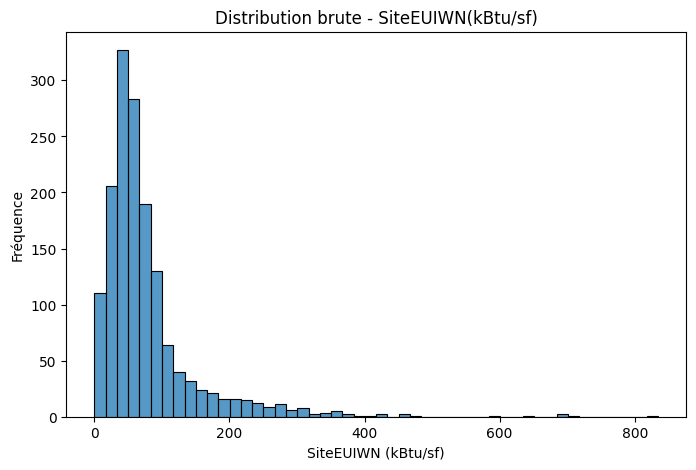

In [72]:
plt.figure(figsize=(8,5))
sns.histplot(building_consumption["SiteEUIWN(kBtu/sf)"], bins=50)
plt.title("Distribution brute - SiteEUIWN(kBtu/sf)")
plt.xlabel("SiteEUIWN (kBtu/sf)")
plt.ylabel("Fréquence")
plt.show()

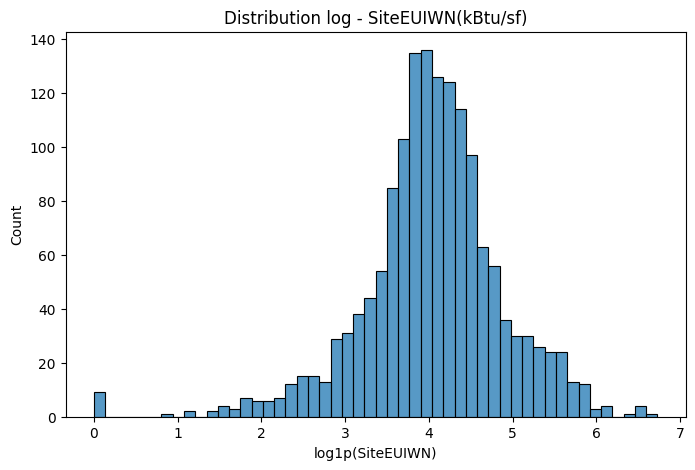

In [73]:
plt.figure(figsize=(8,5))
sns.histplot(
    np.log1p(building_consumption["SiteEUIWN(kBtu/sf)"]),
    bins=50
)
plt.title("Distribution log - SiteEUIWN(kBtu/sf)")
plt.xlabel("log1p(SiteEUIWN)")
plt.show()

In [74]:
building_consumption["SiteEUIWN(kBtu/sf)"].value_counts().head()

SiteEUIWN(kBtu/sf)
0.000000     9
52.299999    6
53.500000    5
56.299999    5
92.300003    5
Name: count, dtype: int64

In [75]:
building_consumption[building_consumption["SiteEUIWN(kBtu/sf)"] == 0]

,BuildingType,PrimaryPropertyType,Latitude,Longitude,NumberofBuildings,NumberofFloors,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SiteEUIWN(kBtu/sf),UseSteam,UseElectricity,UseNaturalGas,NbPropertyUses,BuildingAge,DistToDowntown_km
220,NonResidential,Large Office,47.60370,-122.33447,1.0,17,293925,Office,236827.0,0.0,1,1,0,2,58,0.331993
247,NonResidential,Large Office,47.61695,-122.32965,1.0,20,378769,Office,367623.0,0.0,0,1,1,2,28,1.207997
284,NonResidential,Large Office,47.60923,-122.33625,1.0,15,151039,Office,125473.0,0.0,1,1,0,1,87,0.459310
350,NonResidential,Small- and Mid-Sized Office,47.62014,-122.35768,1.0,5,66400,Office,69691.0,0.0,0,1,0,2,45,2.466684
882,NonResidential,Worship Facility,47.67572,-122.32850,1.0,2,23931,Assembly,23931.0,0.0,0,1,1,1,106,7.733843
953,NonResidential,Worship Facility,47.68752,-122.29852,1.0,2,31386,Assembly,30000.0,0.0,0,1,1,1,16,9.384152
3274,Campus,University,47.65644,-122.31041,111.0,1,9320156,Education,9320156.0,0.0,1,1,0,1,116,5.816442
3275,NonResidential,University,47.65395,-122.30584,1.0,4,58779,Education,58779.0,0.0,0,1,0,1,47,5.660731
3277,NonResidential,University,47.65356,-122.30613,1.0,6,203030,Education,203030.0,0.0,0,1,0,1,18,5.612523


In [76]:
building_consumption = building_consumption[building_consumption["SiteEUIWN(kBtu/sf)"] > 0]

print("Shape après suppression des outliers de la cible :", building_consumption.shape)

Shape après suppression des outliers de la cible : (1536, 16)


Matrices de corrélation des valeurs numériques

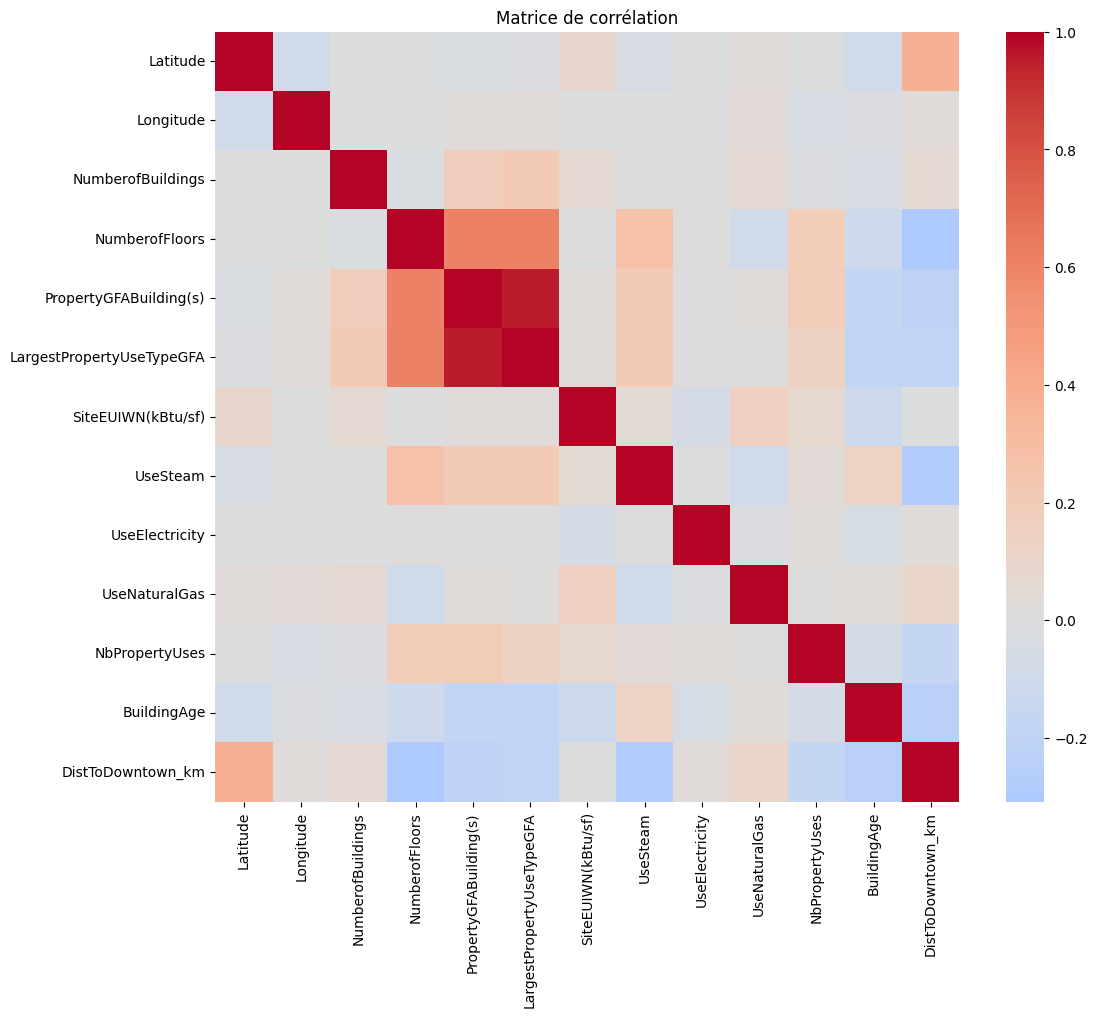

In [77]:
# On sélectionne uniquement les variables numériques
numeric_features = building_consumption.select_dtypes(include=[np.number])

corr_matrix = numeric_features.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.show()

In [78]:
corr_matrix.loc["PropertyGFABuilding(s)", "LargestPropertyUseTypeGFA"]

np.float64(0.950288447071902)

In [79]:
building_consumption = building_consumption.drop(columns=["LargestPropertyUseTypeGFA"])

In [80]:
print("Shape après suppression de LargestPropertyUseTypeGFA :", building_consumption.shape)

Shape après suppression de LargestPropertyUseTypeGFA : (1536, 15)


In [81]:
building_consumption.info()

<class 'pandas.DataFrame'>
Index: 1536 entries, 0 to 3375
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   BuildingType            1536 non-null   str    
 1   PrimaryPropertyType     1536 non-null   str    
 2   Latitude                1536 non-null   float64
 3   Longitude               1536 non-null   float64
 4   NumberofBuildings       1536 non-null   float64
 5   NumberofFloors          1536 non-null   int64  
 6   PropertyGFABuilding(s)  1536 non-null   int64  
 7   LargestPropertyUseType  1536 non-null   str    
 8   SiteEUIWN(kBtu/sf)      1536 non-null   float64
 9   UseSteam                1536 non-null   int64  
 10  UseElectricity          1536 non-null   int64  
 11  UseNaturalGas           1536 non-null   int64  
 12  NbPropertyUses          1536 non-null   int64  
 13  BuildingAge             1536 non-null   int64  
 14  DistToDowntown_km       1536 non-null   float64
dtypes: 

Scatterplots — variables numériques

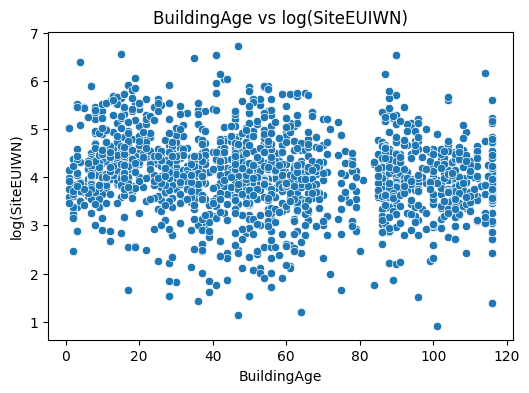

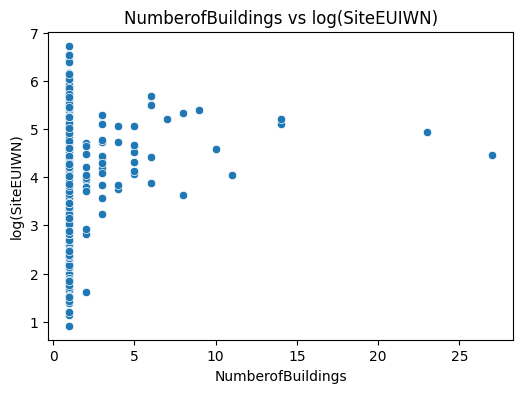

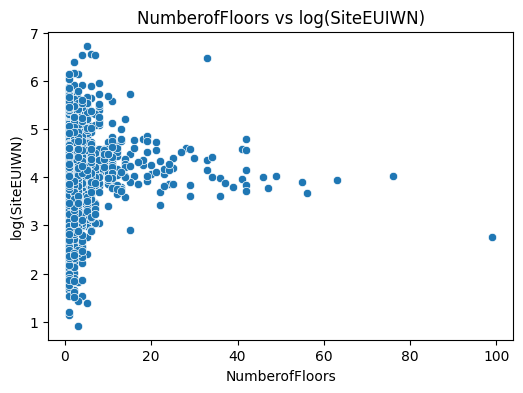

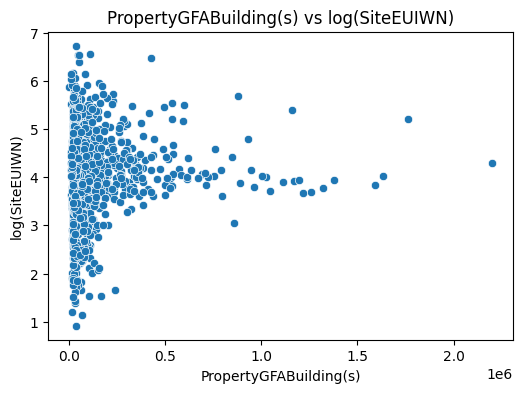

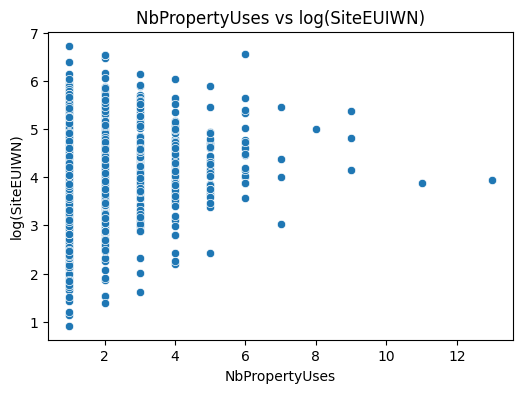

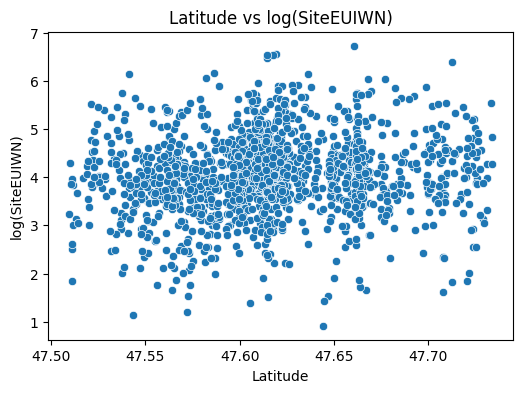

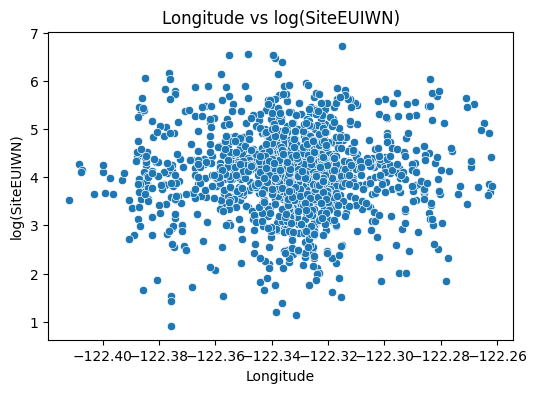

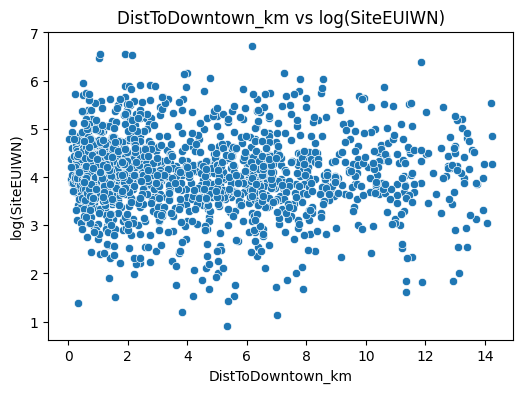

In [82]:
y = np.log1p(building_consumption["SiteEUIWN(kBtu/sf)"])

numeric_cols = [
    "BuildingAge",
    "NumberofBuildings",
    "NumberofFloors",
    "PropertyGFABuilding(s)",
    "NbPropertyUses",
    "Latitude",
    "Longitude",
    "DistToDowntown_km"
]

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=building_consumption[col], y=y)
    plt.title(f"{col} vs log(SiteEUIWN)")
    plt.xlabel(col)
    plt.ylabel("log(SiteEUIWN)")
    plt.show()

Boxplots — variables catégorielles

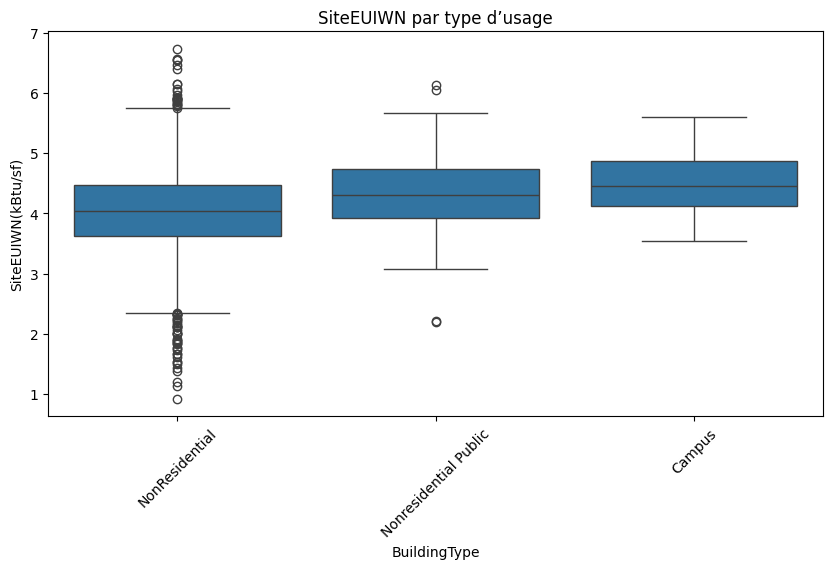

In [83]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x="BuildingType",
    y=y,
    data=building_consumption
)
plt.xticks(rotation=45)
plt.title("SiteEUIWN par type d’usage")
plt.show()

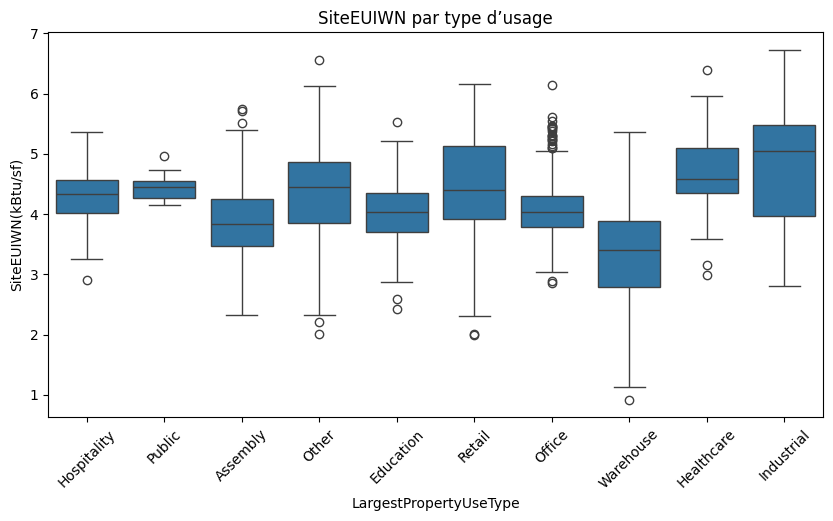

In [84]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x="LargestPropertyUseType",
    y=y,
    data=building_consumption
)
plt.xticks(rotation=45)
plt.title("SiteEUIWN par type d’usage")
plt.show()

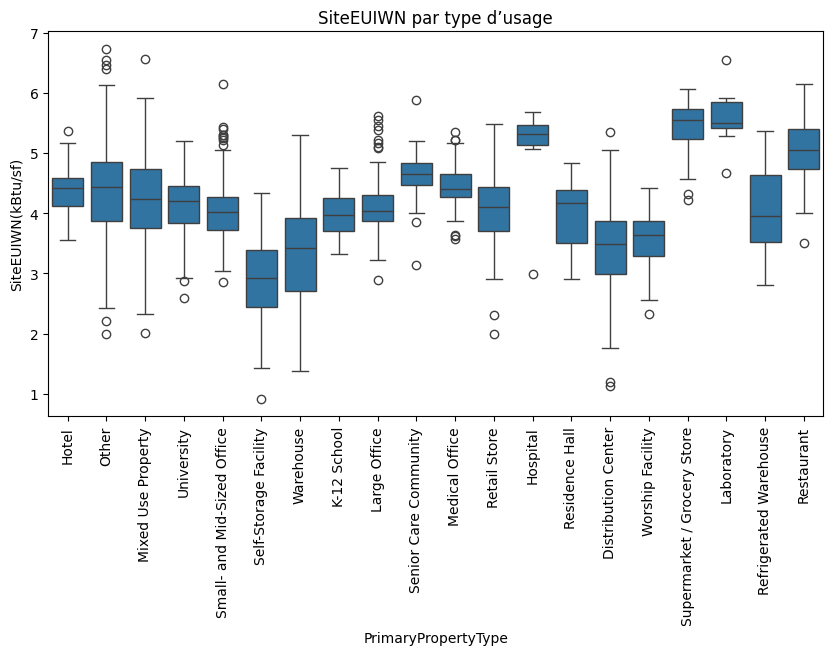

In [85]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x="PrimaryPropertyType",
    y=y,
    data=building_consumption
)
plt.xticks(rotation=90)
plt.title("SiteEUIWN par type d’usage")
plt.show()

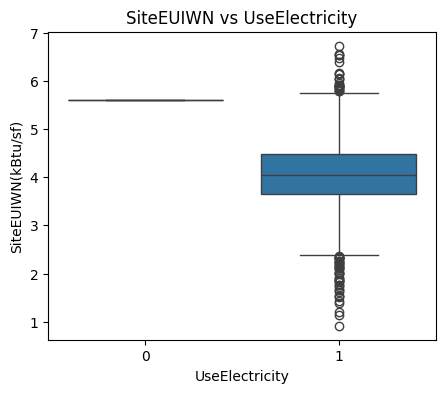

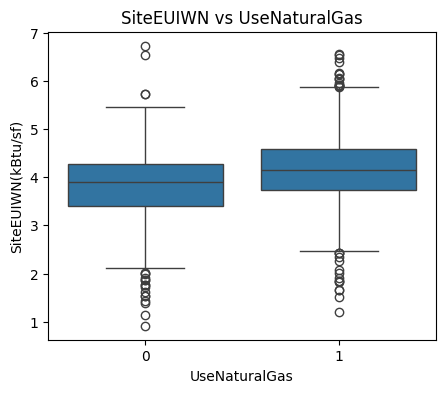

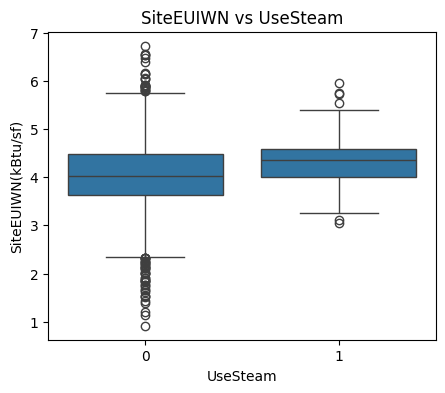

In [86]:
mix_cols = ["UseElectricity", "UseNaturalGas", "UseSteam"]

for col in mix_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(x=building_consumption[col], y=y)
    plt.title(f"SiteEUIWN vs {col}")
    plt.show()

Définir X brut et y (target)

In [87]:
TARGET = "SiteEUIWN(kBtu/sf)"

# y = target (Series)
y = building_consumption[TARGET]

# X brut = toutes les features (DataFrame)
X = building_consumption.drop(columns=[TARGET])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1536, 14)
y shape: (1536,)


Définir les listes de colonnes (catégorielles / numériques / booléennes)

In [88]:
categorical_cols = ["BuildingType", "PrimaryPropertyType", "LargestPropertyUseType"]

numeric_cols = [
    "Latitude", "Longitude", "DistToDowntown_km",
    "BuildingAge",
    "NumberofBuildings", "NumberofFloors",
    "PropertyGFABuilding(s)", "NbPropertyUses"
]

boolean_cols = ["UseSteam", "UseElectricity", "UseNaturalGas"]

Construire le ColumnTransformer (OneHotEncoder + StandardScaler + passthrough)

In [89]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", StandardScaler(), numeric_cols),
        ("bool", "passthrough", boolean_cols),
    ],
    remainder="drop"
)

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [90]:
# CODE COMPARAISON DES MODELES

Construire les pipelines modèles

In [91]:
pipelines = {
    "Dummy": Pipeline([("prep", preprocessor), ("model", DummyRegressor(strategy="median"))]),
    "LinearRegression": Pipeline([("prep", preprocessor), ("model", LinearRegression())]),
    "SVR": Pipeline([("prep", preprocessor), ("model", SVR())]),
    "RandomForest": Pipeline([("prep", preprocessor), ("model", RandomForestRegressor(random_state=42))]),
    "GradientBoosting": Pipeline([("prep", preprocessor), ("model", GradientBoostingRegressor(random_state=42))])
}

Cross-validate

In [92]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring)
    print(
        name,
        "RMSE:", -scores["test_rmse"].mean(),
        "MAE:",  -scores["test_mae"].mean(),
        "R2:",    scores["test_r2"].mean()
    )

Dummy RMSE: 78.63554153902116 MAE: 42.987594659373485 R2: -0.08413053408246096
LinearRegression RMSE: 62.15507160473648 MAE: 36.628892955101456 R2: 0.3178460119564194
SVR RMSE: 76.27302935389741 MAE: 40.56070713822963 R2: -0.020493699046519452
RandomForest RMSE: 61.2308361897577 MAE: 36.94374072731826 R2: 0.3358997418342321
GradientBoosting RMSE: 61.46559629538975 MAE: 36.29519419836753 R2: 0.3270272392895691


In [93]:
pipelines["RandomForest_logy"] = Pipeline([
    ("prep", preprocessor),
    ("model", TransformedTargetRegressor(
        regressor=RandomForestRegressor(random_state=42),
        func=np.log,
        inverse_func=np.exp
    ))
])

In [94]:
pipe = pipelines["RandomForest_logy"]

scores = cross_validate(
    pipe,
    X,
    y,
    cv=5,
    scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"]
)

print(
    "RandomForest_logy",
    "RMSE:", -scores["test_neg_root_mean_squared_error"].mean(),
    "MAE:", -scores["test_neg_mean_absolute_error"].mean(),
    "R2:", scores["test_r2"].mean()
)

RandomForest_logy RMSE: 62.71761904994635 MAE: 33.690529185761086 R2: 0.3067422859318132


### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 

In [95]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE

GridSearch sur RandomForest

In [96]:
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [97]:
param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 3, 5],
}

In [98]:
grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X, y)

print("Paramètres optimisés sur grille limitée:", grid.best_params_)
print("Meilleur R2:", grid.best_score_)

Paramètres optimisés sur grille limitée: {'model__max_depth': 20, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}
Meilleur R2: 0.37056992919893383


In [99]:
param_grid = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2, 3, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__max_features": ["sqrt", 0.5],
}

In [100]:
grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X, y)

print("Paramètres optimisés sur grille étendue:", grid.best_params_)
print("Meilleur R2:", grid.best_score_)

Paramètres optimisés sur grille étendue: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Meilleur R2: 0.3832687616344595


Feature importance par shap

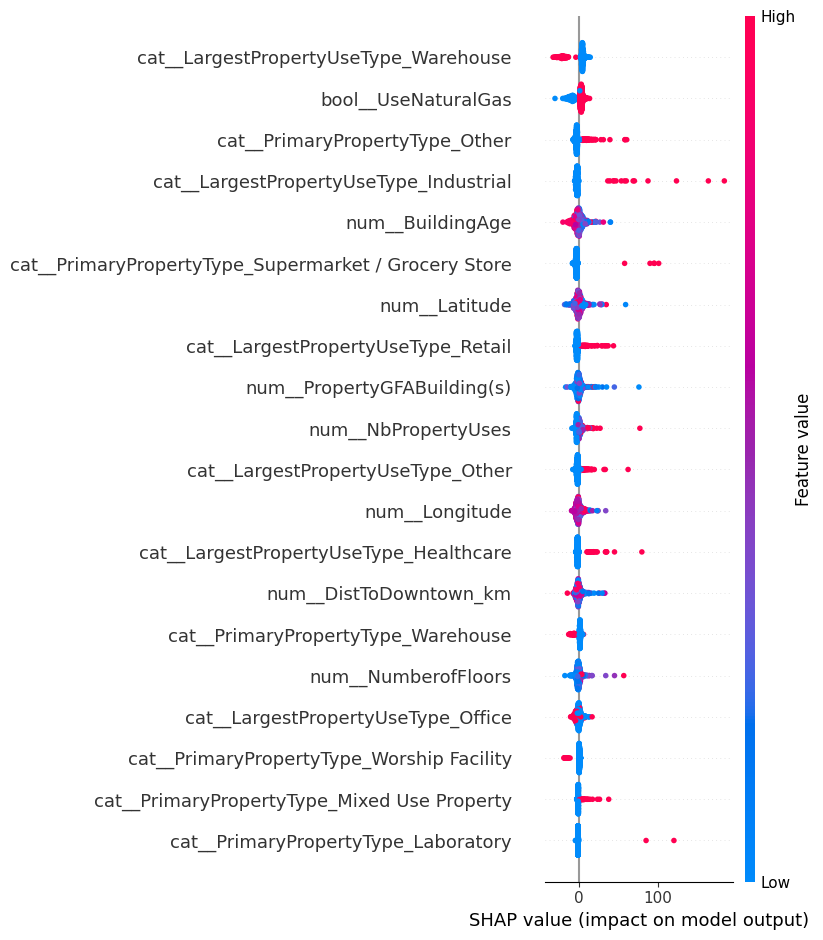

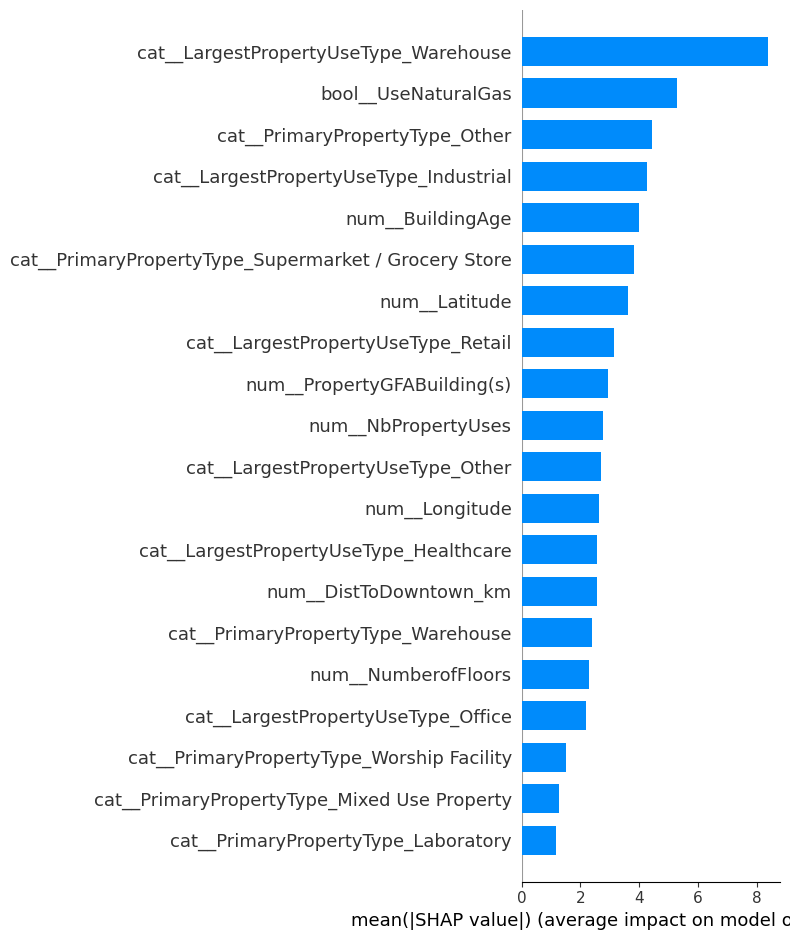

In [101]:
import shap

# Récupérer le meilleur pipeline après GridSearch
best_model = grid.best_estimator_   # Pipeline("prep" -> ColumnTransformer, "model" -> RandomForest)

# Échantillon (SHAP peut être lourd)
X_sample = X.sample(n=min(500, len(X)), random_state=42)

# Transformer X via le preprocessor du pipeline
X_trans = best_model.named_steps["prep"].transform(X_sample)

# Noms des features après transformation
feature_names = best_model.named_steps["prep"].get_feature_names_out()

# Si sortie sparse -> dense (SHAP + plots souvent plus simples)
if hasattr(X_trans, "toarray"):
    X_trans = X_trans.toarray()

X_trans_df = pd.DataFrame(X_trans, columns=feature_names)

# Explainer adapté aux arbres (RandomForest)
rf = best_model.named_steps["model"]
explainer = shap.TreeExplainer(rf)

# Calcul SHAP
shap_values = explainer.shap_values(X_trans_df)

# Graphiques
shap.summary_plot(shap_values, X_trans_df)          # beeswarm
shap.summary_plot(shap_values, X_trans_df, plot_type="bar")  # importance moyenne (bar)

Sauvegarde du meilleur modèle

In [102]:
best_pipeline = grid.best_estimator_  # pipeline complet déjà refit
best_pipeline.get_params()  # optionnel: vérifier

import bentoml

bento_model = bentoml.sklearn.save_model(
    name="seattle_energy_rf",
    model=best_pipeline,
    labels={"project": "oc-de", "project_id": "p06"},
    custom_objects={
        "input_features": list(X.columns),
        "target": TARGET,
        "best_params": grid.best_params_,
    },
)
print("Tag de la sauvegarde du meilleur modèle optimisé:", bento_model.tag)

Tag de la sauvegarde du meilleur modèle optimisé: seattle_energy_rf:6iuuoyyzhwbgekgq
